# Exploring & Cleaning Data with Pandas

**Dataset:** `Sample-Superstore2019.csv` — 9,994 orders from a fictional retail superstore (2016–2019), with columns covering customers, products, shipping, and sales/profit figures.

**Goal of this lecture:** build a repeatable workflow for taking a raw CSV from "just downloaded" to "ready for analysis" — inspecting it, understanding its shape and types, finding and fixing problems, and confirming it's trustworthy before we build anything on top of it.

## Agenda
0. Setup
1. Getting Oriented — Reading & First Look
2. Descriptive Exploration
3. Data Types & Conversions
4. Missing Data
5. Duplicate Detection
6. Inconsistent / Dirty Values
7. Outliers & Sanity Checks
8. Filtering, Selecting & Boolean Indexing
9. Reshaping & Aggregating for Insight
10. Wrap-Up — A Repeatable Cleaning Checklist

Each topic follows the same pattern: **explanation → demo → exercise**. Exercise cells are left blank (with guiding comments) for you to fill while you are studying at home.

## 0. Setup

Before exploring anything we need our tools and our data in memory.

- `pandas` is the core library for tabular data — it gives us the `DataFrame`, the object we'll spend the whole lecture inside.
- `numpy` occasionally helps with numeric operations (e.g. representing missing values, vectorized math).
- `matplotlib` will let us draw quick sanity-check plots (histograms, boxplots) later on.
> **Important Note:**
We load the CSV with `pd.read_csv()`. This one file happens to load fine with the default UTF-8 encoding — but keep in mind that real-world CSVs (especially exports from Excel) often need `encoding="latin1"` or `encoding="cp1252"`. If `read_csv` ever throws a `UnicodeDecodeError`, that's your cue to try a different encoding.

In [ ]:
# Core libraries for this lecture
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read the CSV into a DataFrame.
# If this ever raises UnicodeDecodeError on another file, try encoding="latin1".
df = pd.read_csv("Sample-Superstore2019.csv")

# Quick confirmation that the file loaded and how big it is (rows, columns)
df.shape

: 

In [ ]:
df.to_parquet("Sample-Superstore2019.parquet", index=False)

## 1. Getting Oriented — Reading & First Look

The very first thing to do with any new dataset is **look at it before you touch it**. We want to answer:

- How many rows and columns do we have? (`.shape`)
- What do the first/last few rows actually look like? (`.head()`, `.tail()`)
- What are the column names, and what type does pandas think each one is? (`.columns`, `.dtypes`, `.info()`)

`.info()` is especially useful because it combines row count, column names, non-null counts, and dtypes in one view — it's usually the first command to run on any new DataFrame.

Watch for the `Unnamed: 0` column in the output below. That's a classic artifact of a CSV that was exported *with* its row index included — it's not real data, and cleaning it up (or telling `read_csv` to use it as the index) is itself a small first cleaning step.

In [3]:
# Shape: (number of rows, number of columns)
print("Shape:", df.shape)

# First and last rows — sanity check that data looks like what we expect
df.head()

Shape: (9994, 22)


,Unnamed: 0,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,0,1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,1,2,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,2,3,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,3,4,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,4,5,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.tail(3)

,Unnamed: 0,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9991,9991,9992,CA-2019-121258,2019-02-26,2019-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,...,92627.0,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9992,9993,CA-2019-121258,2019-02-26,2019-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,...,92627.0,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9993,9994,CA-2019-119914,2019-05-04,2019-05-09,Second Class,CC-12220,Chris Cortes,Consumer,United States,...,92683.0,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


In [5]:
# Column names
print(df.columns.tolist())

# .info() gives dtypes + non-null counts + memory usage all at once
df.info()

['Unnamed: 0', 'Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      9994 non-null   int64  
 1   Row ID          9994 non-null   int64  
 2   Order ID        9994 non-null   str    
 3   Order Date      9994 non-null   str    
 4   Ship Date       9994 non-null   str    
 5   Ship Mode       9994 non-null   str    
 6   Customer ID     9994 non-null   str    
 7   Customer Name   9994 non-null   str    
 8   Segment         9994 non-null   str    
 9   Country/Region  9994 non-null   str    
 10  City            9994 non-null   str    
 11  State           9994 non-null   s

### 🧪 Exercise 1 — Getting Oriented

1. Print only the column names of `df` as a Python list.
2. Display the first **7** rows instead of the default 5.
3. Using `.info()`, answer: which column(s), if any, have fewer non-null values than the total row count?
4. `df` was loaded with an extra `Unnamed: 0` column. Look at `pd.read_csv`'s documentation (or `help(pd.read_csv)`) and find the parameter that would let you treat that column as the row index at load time instead.

In [6]:
# TODO 1: print the column names as a list


# TODO 2: display the first 7 rows


# TODO 3: inspect df.info() output and note the column(s) with missing values (write your answer as a comment)


# TODO 4: re-read the CSV using a read_csv parameter that avoids the Unnamed: 0 column


## 2. Descriptive Exploration

Once we know the shape of the data, the next question is: **what values actually live in each column?**

- `.describe()` on numeric columns gives count, mean, std, min, quartiles, and max in one call — a fast way to spot impossible values (e.g. a negative quantity) or extreme outliers hiding in the min/max.
- `.describe(include="object")` (or `include="all"`) does the equivalent for text/categorical columns: count, number of unique values, the most frequent value, and its frequency.
- `.value_counts()` on a single categorical column shows exactly how many rows fall into each category — useful for spotting typos ("Consumer" vs "consumer") or a category that's barely represented.

The goal here isn't to fix anything yet — it's to build intuition about what "normal" looks like in this dataset, so that later, unusual values jump out.

In [7]:
# Summary stats for numeric columns: Sales, Quantity, Discount, Profit, Postal Code, Row ID...
df.describe()

,Unnamed: 0,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9983.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4996.500000,4997.500000,55245.233297,229.858001,3.789574,0.156203,28.656896
std,2885.163629,2885.163629,32038.715955,623.245101,2.225110,0.206452,234.260108
min,0.000000,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2498.250000,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4996.500000,4997.500000,57103.000000,54.490000,3.000000,0.200000,8.666500
75%,7494.750000,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9993.000000,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [8]:
# Summary stats for text/categorical columns
df.describe(include="str")

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State,Region,Product ID,Category,Sub-Category,Product Name
count,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994
unique,5009,1236,1334,4,793,793,3,1,531,49,4,1862,3,17,1850
top,CA-2019-100111,2018-09-05,2017-12-16,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope
freq,14,38,35,5968,37,37,5191,9994,915,2001,3203,19,6026,1523,48


In [9]:
# How many orders per Region / Segment / Ship Mode?
print(df["Region"].value_counts())
print()
print(df["Segment"].value_counts())
print()
print(df["Ship Mode"].value_counts())

Region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64

Segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64

Ship Mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64


### 🧪 Exercise 2 — Descriptive Exploration

1. Run `.describe()` on just the `Sales` and `Profit` columns (hint: select the columns first, then call `.describe()`).
2. Use `.value_counts()` on `Category` — which category has the most orders?
3. Use `.value_counts(normalize=True)` on `Ship Mode` to see the *percentage* of orders per shipping mode instead of raw counts.
4. Looking at the `.describe()` output for `Discount`, does the minimum/maximum look like a plausible discount range? Write your answer as a comment.

In [10]:
# TODO 1: describe() on Sales and Profit only


# TODO 2: value_counts() on Category


# TODO 3: value_counts(normalize=True) on Ship Mode


# TODO 4: comment on whether Discount's min/max look plausible


## 3. Data Types & Conversions

`.info()` already told us the dtype of every column — but dtype is about more than trivia. The *type* pandas assigns determines what operations are even possible:

- `Order Date` and `Ship Date` are loaded as plain `object` (string) columns, not dates — so right now we can't subtract one from the other, sort chronologically, or pull out "just the month." Converting them with `pd.to_datetime()` unlocks all of that.
- Columns with a small, fixed set of repeated text values (like `Segment`, `Region`, `Ship Mode`) are good candidates for the `category` dtype — it uses far less memory and speeds up groupby operations on large datasets.

A good habit: after loading any new CSV, check `.dtypes` and ask "is this the type I actually need, or just the type pandas guessed?" 

In [11]:
df.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      9994 non-null   int64  
 1   Row ID          9994 non-null   int64  
 2   Order ID        9994 non-null   str    
 3   Order Date      9994 non-null   str    
 4   Ship Date       9994 non-null   str    
 5   Ship Mode       9994 non-null   str    
 6   Customer ID     9994 non-null   str    
 7   Customer Name   9994 non-null   str    
 8   Segment         9994 non-null   str    
 9   Country/Region  9994 non-null   str    
 10  City            9994 non-null   str    
 11  State           9994 non-null   str    
 12  Postal Code     9983 non-null   float64
 13  Region          9994 non-null   str    
 14  Product ID      9994 non-null   str    
 15  Category        9994 non-null   str    
 16  Sub-Category    9994 non-null   str    
 17  Product Name    9994 non-null   str    
 18 

In [12]:
df.memory_usage(deep=True)

Index                132
Unnamed: 0         79952
Row ID             79952
Order ID          219868
Order Date        179892
Ship Date         179892
Ship Mode         208106
Customer ID       159904
Customer Name     209570
Segment           168273
Country/Region    209874
City              173203
State             164773
Postal Code        79952
Region            128517
Product ID        229862
Category          207901
Sub-Category      151826
Product Name      449496
Sales              79952
Quantity           79952
Discount           79952
Profit             79952
dtype: int64

In [13]:
# Convert the two date columns from text to real datetime objects
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

# Now that they're real dates, we can do date arithmetic:
# how many days did each order take to ship?
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

df[["Order Date", "Ship Date", "Shipping Days"]].head()

,Order Date,Ship Date,Shipping Days
0,2018-11-08,2018-11-11,3
1,2018-11-08,2018-11-11,3
2,2018-06-12,2018-06-16,4
3,2017-10-11,2017-10-18,7
4,2017-10-11,2017-10-18,7


In [14]:
# Pull the order month/year out now that Order Date is a real datetime
df["Order Month"] = df["Order Date"].dt.month
df["Order Year"] = df["Order Date"].dt.year

# Convert low-cardinality text columns to the 'category' dtype (memory + speed win)
for col in ["Segment", "Region", "Ship Mode", "Category"]:
    df[col] = df[col].astype("category")

df.dtypes

Unnamed: 0                 int64
Row ID                     int64
Order ID                     str
Order Date        datetime64[us]
Ship Date         datetime64[us]
Ship Mode               category
Customer ID                  str
Customer Name                str
Segment                 category
Country/Region               str
City                         str
State                        str
Postal Code              float64
Region                  category
Product ID                   str
Category                category
Sub-Category                 str
Product Name                 str
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64
Shipping Days              int64
Order Month                int32
Order Year                 int32
dtype: object

In [15]:
print(df.info(memory_usage='deep'))
print(df.memory_usage(deep=True))

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Unnamed: 0      9994 non-null   int64         
 1   Row ID          9994 non-null   int64         
 2   Order ID        9994 non-null   str           
 3   Order Date      9994 non-null   datetime64[us]
 4   Ship Date       9994 non-null   datetime64[us]
 5   Ship Mode       9994 non-null   category      
 6   Customer ID     9994 non-null   str           
 7   Customer Name   9994 non-null   str           
 8   Segment         9994 non-null   category      
 9   Country/Region  9994 non-null   str           
 10  City            9994 non-null   str           
 11  State           9994 non-null   str           
 12  Postal Code     9983 non-null   float64       
 13  Region          9994 non-null   category      
 14  Product ID      9994 non-null   str           
 15  Category       

### 🧪 Exercise 3 — Data Types & Conversions

1. Confirm the conversion worked by checking the dtype of `Order Date` (should be `datetime64[ns]`).
2. Create a new column `Order Weekday` containing the name of the weekday each order was placed on (hint: `.dt.day_name()`).
3. What is the *average* `Shipping Days` across all orders?
4. Convert `Sub-Category` to the `category` dtype as well, the same way we did for `Segment`.

In [16]:
# TODO 1: confirm Order Date's dtype


# TODO 2: create an "Order Weekday" column using .dt.day_name()


# TODO 3: compute the average Shipping Days


# TODO 4: convert Sub-Category to category dtype


## 4. Missing Data

Real datasets almost always have gaps. Pandas represents a missing value as `NaN` (or `NaT` for missing dates), and the first step is always the same: **find out where the gaps are before deciding what to do about them.**

- `.isnull()` / `.isna()` returns a same-shaped DataFrame of `True`/`False`; chaining `.sum()` turns that into a per-column count of missing values.
- Once you know *where* the nulls are, look at *why* — sometimes there's a pattern (e.g. all missing values belong to the same city) that suggests a smarter fix than a generic one.
- Two broad strategies: **drop** the rows/columns (`.dropna()`) when missing data is rare and unrecoverable, or **fill** them (`.fillna()`) when you can infer a sensible value. Dropping loses information; filling risks inserting a wrong assumption — the right call depends on context, not a fixed rule.

In this dataset, `Postal Code` has 11 missing values. Let's find them.

In [17]:
# Count missing values per column
df.isnull().sum()

Unnamed: 0         0
Row ID             0
Order ID           0
Order Date         0
Ship Date          0
Ship Mode          0
Customer ID        0
Customer Name      0
Segment            0
Country/Region     0
City               0
State              0
Postal Code       11
Region             0
Product ID         0
Category           0
Sub-Category       0
Product Name       0
Sales              0
Quantity           0
Discount           0
Profit             0
Shipping Days      0
Order Month        0
Order Year         0
dtype: int64

In [18]:
# Look at the actual rows with a missing Postal Code — is there a pattern?
df[df["Postal Code"].isnull()][["City", "State", "Postal Code"]]

,City,State,Postal Code
2234,Burlington,Vermont,NaN
5274,Burlington,Vermont,NaN
8798,Burlington,Vermont,NaN
9146,Burlington,Vermont,NaN
9147,Burlington,Vermont,NaN
9148,Burlington,Vermont,NaN
9386,Burlington,Vermont,NaN
9387,Burlington,Vermont,NaN
9388,Burlington,Vermont,NaN
9389,Burlington,Vermont,NaN


In [19]:
# All 11 missing postal codes belong to Burlington, Vermont.
# That's not random -- we can look up the real ZIP code (05401) and fill it in
# rather than dropping 11 otherwise-perfectly-good rows.
df["Postal Code"] = df["Postal Code"].fillna(5401)

# Confirm there are no missing values left in this column
df["Postal Code"].isnull().sum()

np.int64(0)

### 🧪 Exercise 4 — Missing Data

1. Re-run `.isnull().sum()` on the whole DataFrame — confirm every column now shows 0.
2. Suppose instead of filling `Postal Code`, we wanted to simply drop those rows. Write the `.dropna()` call that would do that (don't apply it — just write and run it as a *new* DataFrame so `df` stays intact).
3. In your own words (as a comment), when would dropping rows be the *wrong* choice even if it's the easiest one?

In [20]:
# TODO 1: confirm no missing values remain


# TODO 2: write (but don't overwrite df with) a dropna() call for Postal Code


# TODO 3: comment — when is dropping rows the wrong call?


## 5. Duplicate Detection

Duplicate rows silently distort totals and averages, so it's worth explicitly checking for them rather than assuming a CSV is clean.

- `.duplicated()` flags rows that are **exact repeats** of an earlier row across *every* column; `.sum()` counts them.
- Exact duplicates are the easy case. More often, "duplicate" means something more specific to the business context — e.g. the same `Order ID` + `Product ID` combination appearing twice, which might indicate a data entry error even though the two rows aren't byte-for-byte identical (different Row ID, etc). Pass `subset=[...]` to check duplicates on specific columns only.
- Finding **zero** duplicates is a real, useful result — it doesn't mean the check was pointless, it means you've confirmed something instead of assumed it.

In [21]:
# Exact full-row duplicates
print("Exact duplicate rows:", df.duplicated().sum())

# Duplicates on a more meaningful subset: same order line for the same product
print("Duplicate Order ID + Product ID pairs:", df.duplicated(subset=["Order ID", "Product ID"]).sum())

Exact duplicate rows: 0
Duplicate Order ID + Product ID pairs: 8


In [22]:
# Inspect what those subset-duplicates actually look like
dup_mask = df.duplicated(subset=["Order ID", "Product ID"], keep=False)
df[dup_mask].sort_values(["Order ID", "Product ID"]).head(8)

,Unnamed: 0,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Days,Order Month,Order Year
6498,6498,6499,CA-2017-103135,2017-07-24,2017-07-28,Standard Class,SS-20515,Shirley Schmidt,Home Office,United States,...,Office Supplies,Binders,"GBC Prepunched Paper, 19-Hole, for Binding Sys...",135.09,9,0.0,62.1414,4,7,2017
6500,6500,6501,CA-2017-103135,2017-07-24,2017-07-28,Standard Class,SS-20515,Shirley Schmidt,Home Office,United States,...,Office Supplies,Binders,"GBC Prepunched Paper, 19-Hole, for Binding Sys...",90.06,6,0.0,41.4276,4,7,2017
350,350,351,CA-2018-129714,2018-09-01,2018-09-03,First Class,AB-10060,Adam Bellavance,Home Office,United States,...,Office Supplies,Paper,Xerox 1881,24.56,2,0.0,11.5432,2,9,2018
352,352,353,CA-2018-129714,2018-09-01,2018-09-03,First Class,AB-10060,Adam Bellavance,Home Office,United States,...,Office Supplies,Paper,Xerox 1881,49.12,4,0.0,23.0864,2,9,2018
1300,1300,1301,CA-2018-137043,2018-12-23,2018-12-25,Second Class,LC-17140,Logan Currie,Consumer,United States,...,Furniture,Furnishings,"Electrix Architect's Clamp-On Swing Arm Lamp, ...",572.76,6,0.0,166.1004,2,12,2018
1301,1301,1302,CA-2018-137043,2018-12-23,2018-12-25,Second Class,LC-17140,Logan Currie,Consumer,United States,...,Furniture,Furnishings,"Electrix Architect's Clamp-On Swing Arm Lamp, ...",286.38,3,0.0,83.0502,2,12,2018
9168,9168,9169,CA-2018-140571,2018-03-15,2018-03-19,Standard Class,SJ-20125,Sanjit Jacobs,Home Office,United States,...,Office Supplies,Paper,Xerox 1964,319.76,14,0.0,147.0896,4,3,2018
9169,9169,9170,CA-2018-140571,2018-03-15,2018-03-19,Standard Class,SJ-20125,Sanjit Jacobs,Home Office,United States,...,Office Supplies,Paper,Xerox 1964,45.68,2,0.0,21.0128,4,3,2018


### 🧪 Exercise 5 — Duplicate Detection

1. Check for duplicates using only the `Customer ID` and `Order Date` columns — how many rows come back as duplicates? (Think about what a "duplicate" even means here before assuming it's a problem.)
2. Using `keep="first"` vs `keep="last"` in `.duplicated()`, explain in a comment what the difference is.
3. If you did want to remove duplicate rows, which pandas method would you use (look it up if you're not sure — hint: it's a close cousin of `.duplicated()`)?

In [23]:
# TODO 1: duplicated() on Customer ID + Order Date


# TODO 2: comment explaining keep="first" vs keep="last"


# TODO 3: name (and try) the method that would actually remove duplicate rows


## 6. Inconsistent / Dirty Values

Beyond missing values and duplicate rows, text columns are prone to *inconsistency*: the same real-world value spelled, capitalized, or spaced differently across rows (`"Consumer"` vs `"consumer "` vs `"CONSUMER"`). Pandas will treat each of those as a *different* category, which quietly breaks `.value_counts()` and `.groupby()` results.

The habit to build: run `.unique()` on every categorical column and actually read the output, even when you expect it to be clean. Common fixes when something *is* off:

- `.str.strip()` — remove leading/trailing whitespace
- `.str.lower()` / `.str.title()` — normalize casing
- `.replace({...})` — map known typos/variants to a single canonical value

This dataset happens to be clean on this front — which is itself worth confirming rather than assuming.

In [24]:
# Check every key categorical column for stray variants (casing, whitespace, typos)
for col in ["Segment", "Region", "Ship Mode", "Category", "Country/Region"]:
    print(col, "->", df[col].unique())

Segment -> ['Consumer', 'Corporate', 'Home Office']
Categories (3, str): ['Consumer', 'Corporate', 'Home Office']
Region -> ['South', 'West', 'Central', 'East']
Categories (4, str): ['Central', 'East', 'South', 'West']
Ship Mode -> ['Second Class', 'Standard Class', 'First Class', 'Same Day']
Categories (4, str): ['First Class', 'Same Day', 'Second Class', 'Standard Class']
Category -> ['Furniture', 'Office Supplies', 'Technology']
Categories (3, str): ['Furniture', 'Office Supplies', 'Technology']
Country/Region -> <ArrowStringArray>
['United States']
Length: 1, dtype: str


In [25]:
# Even on a clean column, this is the defensive pattern to reach for
# whenever you *do* find inconsistent casing/whitespace:
df["Segment"] = df["Segment"].astype(str).str.strip().str.title()
df["Segment"].unique()

<ArrowStringArray>
['Consumer', 'Corporate', 'Home Office']
Length: 3, dtype: str

### 🧪 Exercise 6 — Inconsistent / Dirty Values

1. Run `.unique()` on the `Sub-Category` column. Are there any surprises?
2. Simulate a dirty value: create a small test Series like `pd.Series([" consumer", "Consumer ", "CONSUMER"])` and clean it into a single consistent value using `.str.strip()` and `.str.title()` (or `.str.lower()`).
3. In your own words (as a comment): why can inconsistent text values silently break a `.groupby()` later on, even though the data "looks" fine at a glance?

In [26]:
# TODO 1: unique() on Sub-Category


# TODO 2: clean the simulated dirty Series into one consistent value


# TODO 3: comment — why does inconsistent text break groupby later?


## 7. Outliers & Sanity Checks

Not every extreme value is an error — but every extreme value deserves a look. This is where domain knowledge matters as much as code:

- **Range checks**: `Discount` should logically fall between 0 and 1 (0%–100%) — confirming that with `.min()`/`.max()` is a one-line sanity check.
- **Negative values that are *expected***: negative `Profit` looks alarming at first, but in a sales dataset it's a completely legitimate result (an order sold at a loss) — not a data error. The lesson: an "outlier" is only a *mistake* if it violates a real-world constraint, not just because it's far from the mean.
- **Visual checks**: boxplots and histograms make outliers on continuous columns (like `Sales`) easy to spot visually, and the IQR (interquartile range) method gives a numeric way to flag them.

In [27]:
# Range sanity check: Discount should never be negative or above 1 (100%)
print("Discount min/max:", df["Discount"].min(), df["Discount"].max())

# Negative profit is common in this dataset -- a real business signal, not an error
print("Orders sold at a loss:", (df["Profit"] < 0).sum())

Discount min/max: 0.0 0.8
Orders sold at a loss: 1871


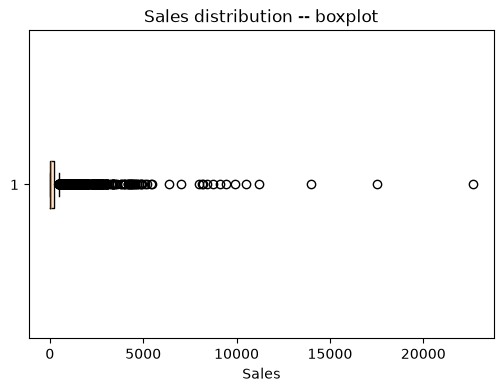

In [28]:
# Visual check for outliers in Sales using a boxplot
plt.figure(figsize=(6, 4))
plt.boxplot(df["Sales"], orientation="horizontal")
plt.title("Sales distribution -- boxplot")
plt.xlabel("Sales")
plt.show()

In [29]:
# IQR method: flag numeric outliers beyond 1.5x the interquartile range
q1 = df["Sales"].quantile(0.25)
q3 = df["Sales"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[(df["Sales"] < lower_bound) | (df["Sales"] > upper_bound)]
print(f"Sales outlier bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
print("Number of Sales outliers:", len(outliers))

Sales outlier bounds: [-271.71, 498.93]
Number of Sales outliers: 1167


### 🧪 Exercise 7 — Outliers & Sanity Checks

1. Apply the same IQR outlier method shown above, but to the `Profit` column instead of `Sales`.
2. Draw a boxplot for `Quantity` — does it show many outliers? What does that tell you about how order quantities are distributed?
3. Is a `Quantity` of 0 or negative possible in this dataset? Check with a range sanity check, similar to the `Discount` check above.

In [30]:
# TODO 1: IQR outlier method applied to Profit


# TODO 2: boxplot for Quantity


# TODO 3: range sanity check on Quantity (min/max)


## 8. Filtering, Selecting & Boolean Indexing

Cleaning inevitably raises questions like "show me just the rows where X is true" — this is where `.loc`, `.iloc`, and boolean indexing come in.

- `.loc[row_selector, column_selector]` selects by **label** (column names, index labels, or a boolean condition).
- `.iloc[row_positions, column_positions]` selects by **integer position**, regardless of labels.
- A boolean condition like `df["Profit"] < 0` produces a `True`/`False` Series the same length as `df`; passing it into `df[...]` or `df.loc[...]` filters to just the matching rows.
- Conditions can be combined with `&` (and), `|` (or) — each condition **must** be wrapped in parentheses because of Python operator precedence.

These techniques are what let us act on everything we found while cleaning — e.g. actually pulling up the loss-making orders we noticed in Section 7.

In [31]:
# Boolean indexing: orders sold at a loss
loss_orders = df[df["Profit"] < 0]
print("Loss-making orders:", len(loss_orders))
loss_orders[["Order ID", "Product Name", "Sales", "Profit"]].head()

Loss-making orders: 1871


,Order ID,Product Name,Sales,Profit
3,US-2017-108966,Bretford CR4500 Series Slim Rectangular Table,957.5775,-383.0310
14,US-2017-118983,Holmes Replacement Filter for HEPA Air Cleaner...,68.8100,-123.8580
15,US-2017-118983,Storex DuraTech Recycled Plastic Frosted Binders,2.5440,-3.8160
23,US-2019-156909,"Global Deluxe Stacking Chair, Gray",71.3720,-1.0196
27,US-2017-150630,"Riverside Palais Royal Lawyers Bookcase, Royal...",3083.4300,-1665.0522


In [32]:
# Combine multiple conditions with & (remember the parentheses around each condition!)
same_day_west = df[(df["Ship Mode"] == "Same Day") & (df["Region"] == "West")]
same_day_west[["Order ID", "Region", "Ship Mode", "Sales"]].head()

,Order ID,Region,Ship Mode,Sales
746,CA-2016-124429,West,Same Day,567.12
747,CA-2016-124429,West,Same Day,359.32
813,CA-2019-143686,West,Same Day,18.28
814,CA-2019-143686,West,Same Day,1399.93
882,US-2019-123463,West,Same Day,13.48


In [33]:
# .loc for label-based selection: rows where Profit < 0, only a few relevant columns
df.loc[df["Profit"] < 0, ["Order ID", "Category", "Sub-Category", "Profit"]].head()

# .iloc for pure position-based selection: first 5 rows, first 3 columns
df.iloc[:5, :3]

,Unnamed: 0,Row ID,Order ID
0,0,1,CA-2018-152156
1,1,2,CA-2018-152156
2,2,3,CA-2018-138688
3,3,4,US-2017-108966
4,4,5,US-2017-108966


### 🧪 Exercise 8 — Filtering, Selecting & Boolean Indexing

1. Filter `df` to only orders in the `Technology` category with `Sales` greater than 1000.
2. Using `.loc`, select the `Order ID`, `Customer Name`, and `Profit` columns for all orders where `Discount` is greater than 0.5.
3. Using `.iloc`, select the last 5 rows and the last 4 columns of `df`.
4. Combine three conditions: orders from the `Consumer` segment, in the `Central` region, shipped `Standard Class` — how many orders match all three?

In [34]:
# TODO 1: Technology orders with Sales > 1000


# TODO 2: .loc selection -- Order ID, Customer Name, Profit where Discount > 0.5


# TODO 3: .iloc -- last 5 rows, last 4 columns


# TODO 4: combine three conditions with &


## 9. Reshaping & Aggregating for Insight

This is the payoff: once data is clean and correctly typed, `.groupby()` and `.pivot_table()` turn thousands of individual rows into answers.

- `.groupby("column")` splits the DataFrame into groups sharing the same value in that column; chaining an aggregation (`.sum()`, `.mean()`, `.agg()`) collapses each group into a single summary row.
- `.pivot_table()` is a more flexible version of `groupby` — it lets you spread one categorical column across the *columns* of the result, which is often exactly the shape you want for a report or a chart.
- `.sort_values()` orders the final result so the most/least interesting rows are easy to spot.

Notice how every prior section feeds into this one: correct dtypes make aggregation meaningful, cleaned categories make grouping trustworthy, and handled missing/duplicate data means the resulting numbers are actually correct.

In [35]:
# Total profit and sales per Region, sorted from most to least profitable
region_summary = df.groupby("Region", observed=True)[["Sales", "Profit"]].sum().sort_values("Profit", ascending=False)
region_summary

,Sales,Profit
Region,,
West,725457.8245,108418.4489
East,678781.2400,91522.7800
South,391721.9050,46749.4303
Central,501239.8908,39706.3625


In [36]:
# Multiple aggregations at once with .agg()
category_summary = df.groupby("Category", observed=True).agg(
    total_sales=("Sales", "sum"),
    avg_profit=("Profit", "mean"),
    orders=("Order ID", "count"),
)
category_summary

,total_sales,avg_profit,orders
Category,,,
Furniture,741999.7953,8.699327,2121
Office Supplies,719047.0320,20.327050,6026
Technology,836154.0330,78.752002,1847


In [37]:
# pivot_table: average Sales by Region (rows) x Category (columns)
pivot = pd.pivot_table(
    df,
    values="Sales",
    index="Region",
    columns="Category",
    aggfunc="mean",
    observed=True,
)
pivot

Category,Furniture,Office Supplies,Technology
Region,,,
Central,340.534644,117.458801,405.753124
East,346.574383,120.044425,495.278469
South,353.309289,126.282727,507.753952
West,357.302325,116.422377,420.687533


### 🧪 Exercise 9 — Reshaping & Aggregating for Insight

1. Group by `Sub-Category` and find total `Profit` per sub-category, sorted ascending (most loss-making first). Which sub-category loses the most money overall?
2. Build a pivot table showing total `Sales` with `Segment` as rows and `Ship Mode` as columns.
3. Using `.groupby()` with `.agg()`, compute both the average and the maximum `Shipping Days` (from Section 3) per `Ship Mode`.

In [38]:
# TODO 1: total Profit per Sub-Category, sorted ascending


# TODO 2: pivot table -- Sales by Segment (rows) x Ship Mode (columns)


# TODO 3: average and max Shipping Days per Ship Mode


## 10. Wrap-Up — A Repeatable Cleaning Checklist

Every dataset is different, but the *process* for approaching one is repeatable. Whenever you open a new CSV, work through the same sequence we just walked through:

1. **Shape & types** — `.shape`, `.info()`, `.dtypes`. What am I working with?
2. **Descriptive stats** — `.describe()`, `.value_counts()`. What does "normal" look like here?
3. **Fix types** — convert dates, numbers, and categories to the dtype they actually represent.
4. **Missing data** — `.isnull().sum()`, then decide drop vs. fill *per column*, based on why it's missing.
5. **Duplicates** — `.duplicated()`, both full-row and on meaningful subsets of columns.
6. **Consistency** — `.unique()` on every categorical column; normalize casing/whitespace/typos.
7. **Outliers** — range checks against domain knowledge, plus boxplots/IQR for a numeric view.
8. **Filter & select** — `.loc`/`.iloc`/boolean indexing to act on everything found above.
9. **Aggregate** — `.groupby()`/`.pivot_table()` to turn clean rows into real answers.

### 🧪 Capstone Exercise

Using everything from this notebook, answer the following in one code cell each:

1. Which `State` generated the highest total `Profit`, and which generated the largest total *loss*?
2. Is there a relationship between `Discount` and `Profit`? (Hint: group `Discount` into bins with `pd.cut()`, then look at average `Profit` per bin.)
3. Pick one thing you noticed while exploring this dataset that *wasn't* covered explicitly in this notebook, and investigate it your own way.

In [39]:
# TODO 1: State with highest total Profit, and State with largest total loss


# TODO 2: relationship between Discount (binned) and average Profit


# TODO 3: your own exploration
